### This Notebook Follows the Chapeter 5 of LLM from Scratch Textbook.

![Alt Text](pics/LLM_Coding_Stages.png)

> Topics Covered in this Chapter 5.

![Alt Text](pics/Chapter5_Covered_Topics.png)

> Running in Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [11]:
#Changing directory to project folder.
%cd /content/drive/MyDrive/AI|ML|DL/LLM_from_Scratch

/content/drive/MyDrive/AI|ML|DL/LLM_from_Scratch


In [12]:
##Checking the files in my drive.
!ls

'Building LLMs From Scratch_Markdown.pdf'
 Build_Reasoning_Model_from_Scratch-Sebastian_Raschka.pdf
 coding_attention_mechanism.ipynb
 conda_environment_creation.txt
 gpt_components.py
 implementing_gpt_from_scratch.ipynb
 LLM_from_Scratch_Sebastian.pdf
 pics
 pretraining_llm.ipynb
 __pycache__
 readme.txt
 requirements.txt
 the-verdict.txt
 working_with_text_data.ipynb


In [ ]:
import torch
import torch.nn as nn
import tiktoken
from gpt_components import GPTModel   #Importing our GPT Model.
import os

In [ ]:
import sys

print("Python:", sys.executable)
print("Working directory:", os.getcwd())

Python: /usr/bin/python3
Working directory: /content/drive/MyDrive/AI|ML|DL/LLM_from_Scratch


In [2]:
#GPT Configuration.
GPT_CONFIG_124M = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 256, # Context length  #Change to 256 from 1024 for Learning
    "emb_dim": 768, # Embedding dimension
    "n_heads": 12, # Number of attention heads
    "n_layers": 12, # Number of layers i.e specifies the number of Transformer blocks in the model
    "drop_rate": 0.1, # Dropout rate
    "qkv_bias": False # Query-Key-Value bias
}

torch.manual_seed(123)
gpt_model = GPTModel(cfg=GPT_CONFIG_124M)
#Since we are using the Model for text generation only so to avoid the dropout and sampling things we use model.eval() mode.
gpt_model.eval()

GPTModel(
  (token_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (CausalMultiHeadAttentionLayer): MultiHeadAttention(
        (W_q): Linear(in_features=768, out_features=768, bias=False)
        (W_k): Linear(in_features=768, out_features=768, bias=False)
        (W_v): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (CausalMultiHeadAttentionLayer): MultiHeadAttention(
        (W_q): Linear(in_features=768, out

![Alt Text](pics/GPT_Text_Generation.png)    


In [3]:
def text_to_token_ids(text:str, tokenizer):

    token_ids = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    token_ids = torch.tensor(token_ids).unsqueeze(0)
    return  token_ids

def token_ids_to_text(token_ids, tokenizer):

    token_ids = token_ids.squeeze(0).tolist()
    text = tokenizer.decode(token_ids)
    return  text


def generate_text_greedy(model, input_idx, max_new_tokens, context_length):

    for _ in range(max_new_tokens):
        input_idx = input_idx[:, -context_length:]   #Input Indices is of Shape:(batch, num_token_ids)
        #Disables gradient tracking since we are not training yet
        with torch.no_grad(): # To avoid storing the computational Graph
            logits = model(input_idx)                   #Output SHape : (batch, num_tokens, vocab_dim)

        logits = logits[:, -1, :]                   #Output Shape: (batch, 1, vocab_dim)
        probas = torch.softmax(input=logits, dim=-1)
        next_token_id = torch.argmax(input=probas, dim=-1, keepdim=True)    #Output SHape:(batch, 1)

        input_idx = torch.cat(tensors=[input_idx, next_token_id], dim=-1)  #Input: cat[(batch, num_tokens), (batch, 1), dim=-1] ; Output Shape: (batch, num_tokens + 1)


    return  input_idx


In [4]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding('gpt2')

In [5]:
token_ids = generate_text_greedy(
    model=gpt_model,
    input_idx=text_to_token_ids(text=start_context, tokenizer=tokenizer),
    max_new_tokens=10,
    context_length=GPT_CONFIG_124M['context_length']
)

output_text = token_ids_to_text(token_ids=token_ids, tokenizer=tokenizer)

print(output_text)

Every effort moves you rentingetic wasnم refres RexMeCHicular stren


> From the genrated output above we can clearly see, the model isn’t yet producing coherent text because it hasn’t undergone training. 

>To define what makes text “coherent” or “high quality,” we have to implement a numerical method to evaluate the generated content.

### 5.1.2 Calculating the text generation loss

![Alt Text](pics/GPT_Text_Generation2.png)

> Let's Start with our Mapped Inputs to Calculate the Loss.

![Alt Text](pics/LLM_Loss_Calculation_Stages.png)

In [6]:
#Batch Inputs for 
#We will give this to the model to get the model output and then check how close it is with our targtes.
inputs = torch.tensor([[16833, 3626, 6100], # ["every effort moves",
                        [40, 1107, 588]]) # "I really like"]

# Matching these inputs, the targets contain the token IDs we want the model to produce:
targets = torch.tensor([[3626, 6100, 345 ], # [" effort moves you",
                        [1107, 588, 11311]]) # " really like chocolate"]

with torch.no_grad():
    logits = gpt_model(inputs)

#Here we keep & get the highest probability across all token position instead of the last one only across all batches.
#Because we want given a set of token the next token so for each token we want to calculate loss for all tokens.
probas = torch.softmax(logits, dim=-1)  #
print(f'Shape of the Probability of the logits:{probas.shape}')

Shape of the Probability of the logits:torch.Size([2, 3, 50257])


In [7]:
#Predicted Tokens at each position of the INput Sequence across all batches.
pred_token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print(pred_token_ids)

tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [21]:
pred_token_ids.shape

torch.Size([2, 3, 1])

In [22]:
pred_token_ids[0].flatten().shape

torch.Size([3])

In [23]:
token_ids_to_text(targets[0], tokenizer)

' effort moves you'

In [24]:
#Let's See the predicted Tokens & Compare with Target.
print(f"Target Batch 1:{token_ids_to_text(targets[0], tokenizer)}")
#Use Flatten Because pred_token_ids[0] gives (batch, num_tokens, 1) to (num_token, 1) in order to make it (num_tokens,)
print(f"Predicted Batch 1: {token_ids_to_text(pred_token_ids[0].flatten(), tokenizer)}")

Target Batch 1: effort moves you
Predicted Batch 1:  Armed heNetflix


> An untrained Model Produces Random Text:

![Alt Text](pics/LLM_Text_Generation_Random.png)

> Now we can also see the Probability assigned to the Target Tokens in the Predicted Probability across Vocab Dim.

- Initially since our vocab is 50257 so ideally in untrained situation the probability should be 1/50257 for each token.
- To adjust the weights of the Network to bring the target token probability higher to we need to use Max Likelihood / Cross Entropy Like Loss Function & use BackPropagation.

In [8]:
#For batch 1 we have 3 tokens & probas is (batch, num_tokens, vocab_dim) i.e (2,3, 50257).
#SO we are taking batch row of first batch i.e 0 th index, then all the token_pos as we want to have the probability of the target_token_index for that position.
#So probas[0, all_token_pos, target_batch_1] i.e probas[0, :, targets[0]] as target is token_id_matrix shape(2, 3) -> (batch, num_tokens)
batch_idx_1 = 0
#Returns Shape: (batch_size, num_tokens, num_tokens)
#But we want (batch_size, num_tokens, 1) or the squeezed version of (batch_size, num_tokens) i.e for each batch the target_token_pred_probability.
# target_batch_prob_1 = probas[batch_idx_1, :, targets[batch_idx_1]]  
#Here we want for 1st/2nd/3rd token the target ground truth probability instead of 1st/2nd/3rd token across all the target_token_idx.
target_batch_prob_1 = probas[batch_idx_1, [0,1,2], targets[batch_idx_1]]  
print(f"Target Token Probability for Batch 1:\n{target_batch_prob_1}")

batch_idx_2 = 1
# target_batch_prob_2 = probas[batch_idx_2, :, targets[batch_idx_2]]
target_batch_prob_2 = probas[batch_idx_2, [0,1,2], targets[batch_idx_2]]

print(f"Target Token Probability for Batch 2:\n{target_batch_prob_2}")

Target Token Probability for Batch 1:
tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
Target Token Probability for Batch 2:
tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


## Cross-Entropy Loss
![Alt Text](pics/CrossEntropyLoss.png)

### Binary Cross-Entropy (BCE)

For y in [0,1] and predicted probability p=P(y=1):

**L_BCE = -[y\*log(p) + (1-y)\*log(1-p)]**

So if y=1 , L_BCE reduces to **L_BCE = y*log(p)** otherwise **(1-y)*log(1-p)**.

### Multiclass Cross-Entropy

For C classes:

**L_CE = sum_i_over_1_to_C(y_i * log(p_i))**

With **one-hot encoding**, only the correct class k has (y_k=1):

Now when y=k then , L_CE reduces to **L_CE = y_k * log(p_k)**


- Generally we want to maximize the Probability that is **p(correct) = 1** or closer to 1 but using probability directly is numerically unstable.

- So we take **Log(p(correct_class))** and our objective becomes **Log(p(correct_class))** closer to 0, as **p(correct_class) = 1** 

- Since probability is in fraction so **Log(probability) <= 0** so in Maximization Term we try to make **Log(Prob)** at max 0.

- But in Deep Learning we try to design objective to minimize loss so we make Log-Likelihood -> Negative Log-Likelihood and try to minimize this so that the our **-Log(p(correct_class))** is closer to 0 as **p(correct_class) = 1** and **-Log(p(correct_class)) >= 0**.



### Batch Level Gradient Update / Parameter Adjustment.
- In LLMs generally we take the loss i.e Negative Log Likelihood , Average them across all tokens in a Batch and then use that loss to update our parameters.

- This is unlike adjusting the parameters for each predicted token where we try to use the collective Batch Loss to update our parameters , so if 6 tokens are there for predicted (batch=2, seq_len=3) then we calculate avergae negative Log Loss and then use it to adjust our weights at once.

In [9]:
#Now let's calculate the log probability and then take average across the batch across all tokens.
log_probas = torch.log(input=torch.cat(tensors=[target_batch_prob_1, target_batch_prob_2], dim=-1))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [10]:
#Now let's take the Average and then take the Negative Log-Likelihood which is our Cross-Entropy Loss.
avg_batch_log_probas = torch.mean(log_probas)

#In Deep learning we try to minimize our loss so here we take Negative of our Avg_Log_Prob instead of Maximizing the avg_batch_log_prob to get upto 0.
#So after that we want to achieve -Log_Likelihood close to 0 but from the positive side.
#Cross Entropy Loss.
neg_avg_log_probas = avg_batch_log_probas * -1
print(f'Cross Entropy Loss for the Batch:{neg_avg_log_probas}')

Cross Entropy Loss for the Batch:10.793965339660645


> Now we will use the Pytorch **nn.Functional.CrossEntropyLoss()** which will do the hard work of Calculating **Cross ENtropy Loss** i.e **Negative Log Likelihood**

- The Pytorch Implementation of CrossENtropy Function Takes Input as Logit unnormalized direct values & the Target Indexes, where they has to be flattened across batch_dim so Logit Probabilities unlike (batch, num_tokens, vocab_dim) has to be (num_tokens * batch, vocab_dim) & Target Indices unlike (batch, num_tokens) has to be (batch * num_tokens,) ; We will use **torch.tensor.flatten()** for this.

- The above is because the implementation takes The input is expected to contain the unnormalized logits for each class (which do not need to be positive or sum to 1, in general). input has to be a Tensor of size (C) for unbatched input or (minibatch, C) for batched_input. 

- And it also takes the Target Indices.

- This Function will apply the softmax function, select the probability scores corresponding to the target IDs, and computed the negative average log probabilities. PyTorch’s cross_entropy function will take care of all these steps

For more info Checkout: https://docs.pytorch.org/docs/2.14/generated/torch.nn.CrossEntropyLoss.html

In [11]:
#Let's get the shape of Logits & Target Shape.
print(f"Logit Shape:{logits.shape} & Target Shape:{targets.shape}")

#Flatten flattens from start to end_dim.
#In Logits We want to have (batch, num_tokens, vocab_dim) to (batch * num_tokens, vocab_dim) so flattening from dim=0 to dim=1
#Instead of just using flatten() without arg which will flatten all dim making it a 1-dimensional vector.
logit_flat = logits.flatten(start_dim=0, end_dim=1)
#In Target we just want to flatten the batch_dim to have (batch, num_tokens) -> (batch*num_tokens,)
target_flat = targets.flatten() #If we dont provide any dim then across all dim is flattened.
print(f"Flattend Logit Shape:{logit_flat.shape} & Flattend Target Shape:{target_flat.shape}")


#Calculating the Loss.
loss = nn.functional.cross_entropy(input=logit_flat, target=target_flat)
print(f"Batch Loss:{loss}")

Logit Shape:torch.Size([2, 3, 50257]) & Target Shape:torch.Size([2, 3])
Flattend Logit Shape:torch.Size([6, 50257]) & Flattend Target Shape:torch.Size([6])
Batch Loss:10.793965339660645


> Notice how the Pytorch Cross Entropy Loss and Our native one result matches to same 10.79.

- Also Check our **Perplexity** which is used alongside **Crossentropy** to evaluate Models on Language Tasks and more intuitive.

### 5.1.3 Calculating the training and validation set losses

In [12]:
from gpt_components import GPTDataset_V1, create_dataloader_v1
torch.manual_seed(123)

> Here first we load the dataset.

In [13]:
with open("the-verdict.txt", 'r') as f:
    text_data = f.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text=text_data))

print(f"Total Characters: {total_characters}")
print(f"Total Tokens:{total_tokens}")

Total Characters: 20479
Total Tokens:5145


With just 5,145 tokens, the text might seem too small to train an LLM, but as mentioned earlier, it’s for educational purposes so that we can run the code in minutes
instead of weeks. Plus, later we will load pretrained weights from OpenAI into our
GPTModel code.

> Now let's split the Text Data into Train & Validation Set.

In [14]:
train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
vaild_data = text_data[split_idx:]

In [32]:
print(vaild_data[:50])

ue' collapsed like a house of cards. He didn't sne


> NOTE:  We are training the model with training data presented in similarly
sized chunks for simplicity and efficiency. However, in practice, it can also be
beneficial to train an LLM with variable-length inputs to help the LLM to better generalize across different types of inputs when it is being used.

In [15]:
#Now let's use our DataLoader Function derived from DataLoader class to get the train & vaildation dataset from Text Data
train_loader = create_dataloader_v1(
    text=train_data,
    max_length=GPT_CONFIG_124M['context_length'],
    batch_size=2,                                #Batch size is 2 for simplicity.
    stride=GPT_CONFIG_124M['context_length'],
    shuffle=True
)

val_loader = create_dataloader_v1(
    text=vaild_data,
    max_length=GPT_CONFIG_124M['context_length'],
    batch_size=2,
    stride=GPT_CONFIG_124M['context_length'],
    shuffle=True
)

#Now let's check our train & avlidation data 
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
 print(x.shape, y.shape)

torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


> Data Prep:

![Alt Text](pics/LLM_Data_Prep.png)

> So there are 9 training Batches with 2 samples in each batch & 1 Validation Batch.

- Next, we implement a utility function to calculate the cross entropy loss of a given
batch returned via the training and validation loader:

In [16]:
#Loss Per Batch Function.
def calc_loss_batch(model, input_batch, target_batch, device):
    '''Function to Calculate Loss per batch.'''

    input_batch = input_batch.to(device)  #Moving to GPU if model is in GPU.  ##Shape: (batch, num_tokens)
    target_batch = target_batch.to(device)   #Shape: (batch, num_tokens)
    logits = model(input_batch)                     #Shape: (batch, num_tokens, vocab_dim)

    loss = nn.functional.cross_entropy(
        input=logits.flatten(0,1),
        target=target_batch.flatten()
    )

    return  loss

> We can now use this calc_loss_batch utility function, which computes the loss for a single batch, to implement the following calc_loss_loader function that computes the loss over all the batches sampled by a given data loader.

### Listing 5.2 Function to compute the training and validation loss across batches to check the Training/Validation performance while training the Model

In [17]:
#Loss on the DataLoader across multiple batches.
def calc_loss_loader(dataloader, model, num_batches=None, device='cpu'):
    '''Function to Calculate AVerage across multiple batches.'''
    #Initially there is no loss.
    total_loss = 0

    #DataLoader is an iterable & if its empty then there is no data.
    if len(dataloader) == 0:
        return float('nan')
    if num_batches == None :
        #If no num_batches given to iterate and calculate loss across guven number of batches then we calc across all batches.
        num_batches = len(dataloader)
    else:
        num_batches = min(num_batches, len(dataloader))

    #dataloader itself return input & target pairs.
    for i, (input_batch, target_batch) in enumerate(dataloader):

        if i < num_batches:
            # logits = model(input_batch) #Input SHape:(batch, seq_len) -> Output SHape:(batch, seq_length, vocab_dim or num_classes)
            # loss = nn.functional.cross_entropy(
            #     input=logits.flatten(0,1), target=target_batch.flatten()
            # )
            loss = calc_loss_batch(model=model, input_batch=input_batch, target_batch=target_batch, device=device)
        else:
            break

        #torch.tensor.items extracts the float value from a 1-d single scalar tensor and gives the value only.
        #So if tensor([2.0]) then .item() return 2.0 but tensor([2,3,4]) here .item() will throw error.
        #Also since here we just want to add the loss value to see the loss across batches we do this loss.item() otheriwise it will also 
        #track the computational graph if torch.no_grad() not activated which is unnecessary for just displaying a value.
        total_loss += loss.item()

    avg_loss_over_batches = total_loss / num_batches

    return  avg_loss_over_batches

In [18]:
#Let's use the above function to calculate intial loss across all the batches.
gpt_model.to('cpu')
with torch.no_grad():
    train_avg_loss = calc_loss_loader(dataloader=train_loader, model=gpt_model)
    val_avg_loss = calc_loss_loader(dataloader=val_loader, model=gpt_model)

print(f"Initial Avg Loss Without any Training in the Train DataLoader:{train_avg_loss}")
print(f"Initial Avg Loss Without any Training in the Validation Data Loader:{val_avg_loss}")

Initial Avg Loss Without any Training in the Train DataLoader:10.987583902147081
Initial Avg Loss Without any Training in the Validation Data Loader:10.981106758117676


> As we have not trained the Model so the Loss is so high , we need to try to bring it down to zero.

### 5.2 Pre-Training an LLM

> NOTE Interested readers can learn about more advanced techniques, **including learning rate warmup**, **cosine annealing**, and **gradient clipping**, in appendix D.

> LLM Pretraining Loop

![Alt Text](pics/LLM_Pretraining_Loop.png)

- Here we will **torch.optim.\<Optimizer\>()** Like Adam, AdamW, RmsProp etc. checkout : https://docs.pytorch.org/docs/2.14/optim.html
for Parameter Optimization/ Update

> Listing 5.3 The main function for pretraining LLMs

- Here we will use the following previously created functions & Variables:
    - **calc_loss_batch**
    - **train_dataloader** & **val_dataloader**
    - **calc_loss_loader**
    - **generate_text_greedy()** , **text_to_token_ids()**, **token_ids_to_text**

- Also we will use optimzer from torch.optim So checkout: https://docs.pytorch.org/docs/2.14/optim.html
    - torch.optim.AdamW().zero_grad()
    - torch.optim.AdamW().step()

- And Gradient Calculation using torch.tensor.backward() from the computational graph. Check: https://docs.pytorch.org/docs/2.14/generated/torch.Tensor.backward.html
    - loss.backward()

Note : 
- AdamW :
Adam optimizers are a popular choice for training deep neural networks. However, in
our training loop, we opt for the AdamW optimizer. AdamW is a variant of Adam that
improves the weight decay approach, which aims to minimize model complexity and
prevent overfitting by penalizing larger weights. This adjustment allows AdamW to
achieve more effective regularization and better generalization; thus, AdamW is frequently used in the training of LLMs.

In [19]:
def evaluate_model(model, train_dataloader, val_dataloader, num_batches):
    '''Function to evaluate a model on selected number of batches'''
    model.eval() #Done to disable Dropout.
    with torch.no_grad():
        train_loss = calc_loss_loader(dataloader=train_dataloader, model=model, num_batches=num_batches)
        val_loss = calc_loss_loader(dataloader=val_dataloader, model=model, num_batches=num_batches)

    model.train()  #Again making in training mode, so that the gloabl model variable doesn't remain in Eval mode.
    return  train_loss, val_loss


def generate_and_print_sample(model, tokenizer, context):
    '''Function to generate texts sample from given context'''
    model.eval()
    context_length = model.pos_emb.weight.shape[0]   #Positional Embedding Weight Matrix has shape of (context_size, embed_size)
    encoded_text = text_to_token_ids(context, tokenizer)
    with torch.no_grad():
        output_token_ids = generate_text_greedy(model=model, input_idx=encoded_text, max_new_tokens=50, context_length=context_length)
    decoded_text = token_ids_to_text(output_token_ids, tokenizer)
    
    print(decoded_text.replace("\n", " "))   #Just replacing newline with empty space.
    model.train()

In [20]:
### Function to Train & Evaluate the Model.
def train_model_simple(model, train_dataloader, val_dataloader, optimizer, num_epoch, eval_iter, eval_freq, tokenizer, context,device='cpu'):
    '''This Function trains the Model for Given No. of Epochs.
        Then at every fixed interval Evaluates & Tracks the Train & Val Loss.
        At Each Epoch checks the text generation capaibility of the model.'''

    train_losses, val_losses, track_tokens_seen = [], [], []  #Tracking Variables across Epochs.
    num_tokens_seen, global_step = 0, -1

    for epoch in range(num_epoch):
        model.train()
        for input_batch, target_batch in train_dataloader:
            
            optimizer.zero_grad()
            loss = calc_loss_batch(model=model, input_batch=input_batch, target_batch=target_batch, device=device)
            loss.backward()
            optimizer.step()

            num_tokens_seen += input_batch.numel()  #Input_Batch Shape :(batch, num_tokens or seq_length)
            global_step += 1

            #Now at every predefined frequency we are checking the loss in traing and Val set.
            if global_step % eval_freq == 0 :

                train_loss, val_loss = evaluate_model(model=model,
                                                      train_dataloader=train_dataloader,
                                                      val_dataloader=val_dataloader,
                                                      num_batches=eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(num_tokens_seen)

                print(
                    f"Epoch:{epoch+1} (Global Step:{global_step})"
                    f"\tTrain Loss:{train_loss}"
                    f"\tVal Loss:{val_loss}"
                )
        
        #At each Epoch Checking the Text Generation capan=bility  with a sample text context.
        generate_and_print_sample(model=model, tokenizer=tokenizer, context=context)

    return  train_losses, val_losses, track_tokens_seen

In [21]:
# Starting the Train Loop.
torch.manual_seed(123)
device = 'cpu'
model = GPTModel(cfg=GPT_CONFIG_124M)
model.to(device)

#Optimizer from Torch, Here we are using the AdamW which has weight decay thing unlike Adam.
optimizer = torch.optim.AdamW(
    params=model.parameters(),
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10

train_losses, val_losses, track_tokens_seen = train_model_simple(
    model=model, train_dataloader= train_loader, val_dataloader=val_loader, optimizer=optimizer,
    num_epoch=10, eval_iter=5, eval_freq=5, tokenizer=tokenizer, context="Every effort moves you"
)

/home/ubnt/anaconda3/envs/nn_env/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch:1 (Global Step:0)	Train Loss:9.781000518798828	Val Loss:9.932807922363281
Epoch:1 (Global Step:5)	Train Loss:8.071825885772705	Val Loss:8.340520858764648
Every effort moves you,,,,,,,,,,,,.                                     
Epoch:2 (Global Step:10)	Train Loss:6.752102088928223	Val Loss:7.0442657470703125
Epoch:2 (Global Step:15)	Train Loss:6.093622016906738	Val Loss:6.597477436065674
Every effort moves you, the,, the,, the,,,,.                                     
Epoch:3 (Global Step:20)	Train Loss:6.197071838378906	Val Loss:6.820860385894775
Epoch:3 (Global Step:25)	Train Loss:5.2369081497192385	Val Loss:6.37219762802124
Every effort moves you.               "I was the picture.      "I was the the picture. "I the honour, and I had"I was.  
Epoch:4 (Global Step:30)	Train Loss:4.856730937957764	Val Loss:6.2771806716918945
Epoch:4 (Global Step:35)	Train Loss:4.207147645950317	Val Loss:6.262346267700195
Every effort moves you, and I had been the picture of the picture.          

> As we can see the training loss has improved drastically but Validdation is not which gives a senswe that the model is memoriziing the training data, which is expcted as the data is too small.

> Let's use the Loss tracking varibales and plot them

In [23]:
!pip install -qU matplotlib

In [24]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
#Copied from book.
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
    epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")

    #Creates a secondx-axis that sharesthe same y-axis 
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    #Invisible plot for aligning ticks
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

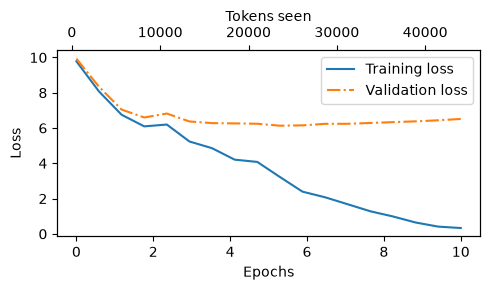

In [25]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, track_tokens_seen, train_losses, val_losses)

The resulting training and validation loss plot is shown in above figure As we can see,
both the training and validation losses start to improve for the first epoch. However,
the losses start to diverge past the second epoch. This divergence and the fact that the
validation loss is much larger than the training loss indicate that the model is overfitting to the training data. We can confirm that the model memorizes the training data
verbatim by searching for the generated text snippets, such as quite insensible to
the irony in the “The Verdict” text file. 

> Now we will move on to Text Decoding Strategies

### 5.3 Decoding strategies to control randomness

### Some Concepts used in Decoding Strategies:

> ### Multinomial Sampling:

Multinomial sampling is a statistical process that generates counts of occurrences for multiple discrete categories across a fixed number of independent trials. 

> Core Concepts

- Fixed Trials (n): You run a set total number of independent experiments or observations.
- Multiple Categories (k): Each trial results in one of k mutually exclusive outcomes (where k > 2).
- Constant Probabilities (p_1, p_2, ..., p_k): Each category has a set probability of occurring on any given trial, and these probabilities sum to 1.
- Dependent Counts: While individual trials are independent, the resulting category counts (X_1, X_2, .... , X_k) are dependent because they must always add up to the total trial count n.

> Relationship to Other Distributions:

- Bernoulli Distribution: A single trial (n = 1) with two outcomes (k = 2).
- Binomial Distribution: Multiple trials (n > 1) with only two outcomes (success/failure, k = 2).
- Categorical Distribution: A single trial (n = 1) with more than two outcomes (k > 2).
- And then we have Multinomial Distribution for multiple trials(n>1) with more than two outcomes or classes (k>2) which is a direct generalization of Binomial Distribution.

> Example:

- Binomial = Flipping a coin 10 times (Count of Heads vs. Tails) 
- Multinomial = Rolling a 6-sided die 10 times (Count of 1s, 2s, 3s, 4s, 5s, and 6s).

> ### Temperature Scaling:

 Temperature scaling is just a fancy description for dividing the logits by a number greater than 0 before applying Softmax.
- Since we know in softmax(z_i) we calculate e^(z_i) / sum(e^z_j) across all vocab_token z_j logits.
- Now Exponentials(e^x) are known for amplifying Higher Values just like Log(x) as an inverse Function is known for suppresing the Higher Values.
- So if we use z_i/T where is T is between (0, +inf) specifically between (0, 5) then for T=1  nothing happens.
- But T < 1 makes the z_scaled = z_i/ T higher and on top as exp(z_scaled) amplifies so it assigns higher prob to higher logits and lower prob to lower logits, making the next_token_prob sharper/peaker and deterministic.
- As we increase T and T > 1 then all logits are equally treated making all the valid token logits almost probable making the next_token_prob flatter or uniform.

- So use T >= 1 if you want more random or creative texts.
- And T < 1 or specifically T < 0.5 when pure deterministic texts.

> 5.3.1 Temperature scaling

In [26]:
#The generate_text_greedy function for our work.
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_greedy(
 model=model,
 input_idx=text_to_token_ids("Every effort moves you", tokenizer),
 max_new_tokens=25,
 context_length=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [27]:
###Let's create a dummy vocab_dict for temperatures scaling.
vocab = {
 "closer": 0,
 "every": 1,
 "effort": 2,
 "forward": 3,
 "inches": 4,
 "moves": 5,
 "pizza": 6,
 "toward": 7,
 "you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}

#Let's create a dummy logit values for these tokens.
next_token_logits = torch.tensor(
 [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [28]:
#Let's see which one from our vocab is the next token using argmax greedy decoding.
probas = torch.softmax(next_token_logits, dim=-1)
next_token_id = torch.argmax(probas, dim=-1).item()
print(f"Next Token based on Greedy decoding:{inverse_vocab[next_token_id]}")

Next Token based on Greedy decoding:forward


> Now To implement a probabilistic sampling process, we can now replace argmax with the multinomial function in PyTorch:

- So Probabilistic Sampling is combination of Multinomial Sampling and temperature scaling

In [29]:
next_token_mnomial = torch.multinomial(input=probas, num_samples=1).item()  #If we want multiple tokens the num_samples > 1
print(f"next_token_mnomial: {inverse_vocab[next_token_mnomial]}")

next_token_mnomial: forward


> The printed output is "forward" just like before. What happened? The multinomial
function samples the next token proportional to its probability score. In other words,
"forward" is still the most likely token and will be selected by multinomial most of
the time but not all the time. To illustrate this, let’s implement a function that repeats
this sampling 1,000 times:

> As we can see, the word forward is sampled most of the time (582 out of 1,000 times),
but other tokens such as closer, inches, and toward will also be sampled some of
the time. This means that if we replaced the argmax function with the multinomial
function inside the generate_and_print_sample function, the LLM would sometimes generate texts such as every effort moves you toward, every effort moves
you inches, and every effort moves you closer instead of every effort moves you
forward

In [30]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


> We can further control the distribution and selection process via a concept called
temperature scaling. Temperature scaling is just a fancy description for dividing the logits
by a number greater than 0

In [31]:
def softmax_with_temperature(logits, temperature=1):
    '''Temperatures greater than 1 result in more uniformly distributed token probabilities,
        and temperatures smaller than 1 will result in more confident (sharper or more peaky)
        distributions'''
    scaled_logits = logits / temperature
    probas = torch.softmax(scaled_logits, dim=-1)
    return probas

> Let’s illustrate the behavior of **temperature scaling** by plotting the original probabilities alongside probabilities scaled with different temperature values:

In [32]:
import matplotlib.pyplot as plt

> Also, as we can see in figure below, applying very small temperatures, such as 0.1, will
result in sharper distributions such that the behavior of the multinomial function
selects the most likely token (here, "forward") almost 100% of the time, approaching
the behavior of the argmax function. Likewise, a temperature of 5 results in a more
uniform distribution where other tokens are selected more often. This can add more
variety to the generated texts but also more often results in nonsensical text. For
example, using the temperature of 5 results in texts such as every effort moves you
pizza about 4% of the time.

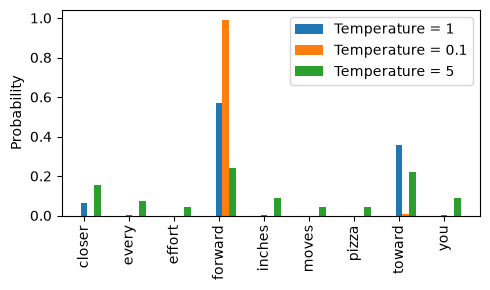

In [33]:
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

### 5.3.2 Top-k Sampling

> Top-k sampling, when combined with probabilistic sampling and temperature scaling, can improve the text generation results. In top-k sampling, we can restrict the sampled tokens to the top-k most likely tokens and exclude all other tokens from the selection process by masking their probability scores, as illustrated in figure below.

![Alt Text](pics/TopK_Sampling.png)

In [34]:
next_token_logits = torch.tensor(
 [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [35]:
#Let's Implement top K.
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


> Checkout torch.where() : https://docs.pytorch.org/docs/2.14/generated/torch.where.html

In [36]:
#Now we can use torch.where() method to make non topk ones -inf.
#we apply PyTorch’s where function to set the logit values of tokens that are below the lowest logit value within our top-three selection to negative infinity (-inf)
new_logits = torch.where(
    condition = next_token_logits < top_logits[-1],   #Identifies logits less than the minimum in the top 3
    input= torch.tensor(float('-inf')),                                #Assigns –inf to these lower logits
    other=next_token_logits                            #Retains the original logits for all other tokens
)

print(f"New Logits after applying Topk:{new_logits}")

#Now we can get the topk probability.
topk_probas = torch.softmax(new_logits, dim=-1)
print(f"TopK Probability:{topk_probas}")

New Logits after applying Topk:tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
TopK Probability:tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


> We can now apply the temperature scaling and multinomial function for probabilistic sampling to select the next token among these three non-zero probability scores to generate the next token. We do this next by modifying the text generation function

### 5.3.3 Modifying the text generation function

- Here we will apply topK Sampling First 
- Then we will apply Multinomial Sampling & Temperature Scaling .

> Listing 5.4 A modified text generation function with more diversity

In [50]:
#TopK, Temperature, Multinomial Implementation in the advanced generate_text function.
def generate_text_advance(model, idx, max_new_tokens, context_length, temperature=0, top_k=None,  eos_id=None):
    '''Function to Generate Advanced Token Generation Strategies.'''

    for _ in range(max_new_tokens) :
        with torch.no_grad():
            idx = idx[:,-context_length:]            #input_idx Shape:(batch, num_tokens)  Convert to Shape:(batch, context_length)
            logits = model(idx)                        #logits Shape:(batch,num_tokens, vocab_dim)
            logits = logits[:, -1, :]                   #logits Shape:(batch, vocab_dim)  If you want (batch, 1,vocab_dim) use a slice logits[:, -1:, :] as with index it only return that element and slice an iterable.

        #Extract top_k.
        if top_k is not None:
            #Filters logits with top_k sampling
            top_k_logits, top_k_pos = torch.topk(input=logits, k=top_k)  #torch.topk() can handle batch of inputs and for each input it seprately does topk. #Output Shape:(batch, top_k)
            min_val = top_k_logits[:,-1]
            logits = torch.where(
                condition = logits < min_val,     #For each row in batch taking the minimum element 
                input = torch.tensor(float('-inf')).to(logits.device),
                other = logits
            )
        if temperature > 0:
            logits = logits / temperature
            probas = torch.softmax(logits, dim=-1)              
            next_idx = torch.multinomial(input=probas, num_samples=1)       #Shape:(batch, 1) So for a batch of sequences (batch, num_tokens) given this is the batch_output.
        
        else:
            #Carries out greedy nexttoken selection as before when temperature scaling is disabled
            probas = torch.softmax(logits, dim=-1)
            next_idx = torch.argmax(input=probas, dim=-1)

        #Stops generating early if end-of-sequence token is encountered
        if next_idx == eos_id: #If EOS Token Id matches our next_token_id then exit generating sequences.
            break

        idx = torch.cat(tensors=[idx, next_idx], dim=-1)   #Input Shapes: (batch, num_tokens) & (bathc, 1) -> Output SHape: (batch, num_tokens+1)

    return  idx

> Let's Compare the Advance and Greedy Text Generation Function.

In [ ]:
#Using Advance Text Generation Function.
torch.manual_seed(123)
#During generation we are using manual seed is because otheriwse the choice of Multinomial Sampling after temperature will change if we dont set seed.
#Because that is the only Random Part in our Token Generation as we know the network is Purely Deterministic.
advanced_output_ids = generate_text_advance(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_length=GPT_CONFIG_124M['context_length'],
    top_k=25,
    temperature=1.4  #,
    #One can use the eos one as well.
    # eos_id=50256        #Because gpt2 tokenizer has eos or . token indexed as 13.
)

print(f"Output of Advance Text generation Function is :\n{token_ids_to_text(token_ids=advanced_output_ids, tokenizer=tokenizer)}")

Output of Advance Text generation Function is :
Every effort moves you know."
" surprise up his for me to the- good of the donkey--so of the tones surprise to




In [67]:
#Using Greedy/Simple Text Generation Function.
greedy_output_ids = generate_text_greedy(
    model=model,
    input_idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_length=GPT_CONFIG_124M['context_length']
)

print(f"\nOutput of Greedy/Simple Text generation Function  is :\n{token_ids_to_text(token_ids=greedy_output_ids, tokenizer=tokenizer)}")


Output of Greedy/Simple Text generation Function  is :
Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




> As we can see Greedy decoding is Different from TopK, temperature, Multinomial based Decoding.

> Some Exercises:

##### Exercise 5.2

> Play around with different temperatures and top-k settings. Based on your observations, can you think of applications where lower temperature and top-k settings are
desired? Likewise, can you think of applications where higher temperature and top-k settings are preferred? (It’s recommended to also revisit this exercise at the end of
the chapter after loading the pretrained weights from OpenAI.)

#### Exercise 5.3
> What are the different combinations of settings for the generate function to force
deterministic behavior, that is, disabling the random sampling such that it always produces the same outputs similar to the generate_simple function?

### 5.5 Loading pretrained weights from OpenAI & also Saving Weights.

> Saving a Model & Loading it in Torch Code.

In [74]:
# We can use the torch.save method:
model_path = "Model"
os.mkdir(model_path)
torch.save(model.state_dict(), f"{model_path}/gpt2_learning.pth")
# Once saved, the model can be loaded:
# model_state_dict = torch.load("review_classifier.pth, map_location=device")
# model.load_state_dict(model_state_dict)

> Adaptive optimizers such as AdamW store additional parameters for each model
weight. AdamW uses historical data to adjust learning rates for each model parameter
dynamically. Without it, the optimizer resets, and the model may learn suboptimally
or even fail to converge properly, which means it will lose the ability to generate coherent text. Using torch.save, we can save both the model and optimizer state_dict
contents:

In [79]:
#Saving the Model & Optimizer State as well.
torch.save({
 "model_state_dict": model.state_dict(),
 "optimizer_state_dict": optimizer.state_dict(),
 },
 f"{model_path}/gpt2_model_and_optimizer.pth"
)
# Then we can restore the model and optimizer states by first loading the saved data via torch.load and then using the load_state_dict method:
checkpoint = torch.load(f"{model_path}/gpt2_model_and_optimizer.pth", map_location=device)
 
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

model.train()

GPTModel(
  (token_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (CausalMultiHeadAttentionLayer): MultiHeadAttention(
        (W_q): Linear(in_features=768, out_features=768, bias=False)
        (W_k): Linear(in_features=768, out_features=768, bias=False)
        (W_v): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (CausalMultiHeadAttentionLayer): MultiHeadAttention(
        (W_q): Linear(in_features=768, out

In [ ]:
optimizer.state_dict()

> Loading Whole Pretrained Weights from OpenAI

In [1]:
!pip install -qU tensorflow tqdm

In [2]:
!pip install -qU transformers  #This one is from HuggingFace.

In [82]:
import urllib.request
url = (
 "https://raw.githubusercontent.com/rasbt/"
 "LLMs-from-scratch/main/ch05/"
 "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7f50a2fd7f80>)

 We can now import the download_and_load_gpt2 function from the gpt_download
.py file as follows, which will load the GPT-2 architecture settings (settings) and
weight parameters (params) into our Python session:

In [84]:
from gpt_download import download_and_load_gpt2

settings, params = download_and_load_gpt2(
 model_size="124M", models_dir="gpt2"
)

I0000 00:00:1790245070.568659  757915 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 472kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 638kiB/s] 
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 615kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [02:11<00:00, 3.78MiB/s]   
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 15.1MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 429kiB/s]  
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 443kiB/s]  
W0000 00:00:1790245214.890033  757915 cpu_allocator_impl.cc:82] Allocation of 154389504 exceeds 10% of free system memory.


In [85]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


> Instead of Downloading like the above outdated method we can use HuggingFace's Current Method from Trandformers Library.

### The Hugging Face mental model

1. Model Weights
2. Tokenizer Vocab
3. Config ARchitecture

- For Any Model Tokenizer use **AutoTokenizer** and for Model Weights of Encoder, For Task SPecific or Decoder based Models like GPT/LLama/Mistral use **AutoModel**, **AutoModelForSequenceClassification**, **AutoModelForCausalLM**
- Along with that use th .from_pretrained('<HuggingFaceModelHubName>').
- By default models ae intially store in ./cache/hf but we can save both Tokenizer & Model Weights Along with config files using 
    - model.save_pretrained("<folder_path>")
    - tokenizer.save_pretrained("<folder_path>")

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

#The Model Repo in HuggingFaceHub
model_name = "openai-community/gpt2"

#Lodaing Model Weights & Model Weights & Config
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

/home/saikat/miniconda3/envs/nn_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7253.44it/s]


In [ ]:
#Now we can save the Model Tokenizer, Weights & Config Files.
tokenizer.save_pretrained('Model/gpt2_hf/')
model.save_pretrained('Model/gpt2_hf/')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.22it/s]


In [89]:
print(model)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


### Now we need to load the model weigths from either of them to our GPTModel() for Finetuning.